In [1]:
from utils._example_traj import _draw_all_sample_traj

In [2]:
import os.path

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import matplotlib.cm as cm
from matplotlib.gridspec import GridSpec
import pickle

sample_index = [2313, 6512, 8111,
                12234, 18567, 18841,
                22232, 27811, 26133,
                33111, 36712, 37817,
                43991, 41231, 48131,
                51311, 57675, 59813,
                65120, 67588, 68751]

def _draw_example_traj(dataset, gradcam, idx, ax):
    trajectory_data_x = dataset[0][idx][0][0]  # Replace this with your actual trajectory data, x axis
    # trajectory_data_y = dataset[0][idx][0][1]  # Replace this with your actual trajectory data, y axis

    attribution_values = gradcam[idx]  # Replace this with your attribution values
    attribution_values = MinMaxScaler().fit_transform(attribution_values.reshape(-1, 1)).flatten()

    cmap = plt.get_cmap('RdBu_r')
    sm = plt.cm.ScalarMappable(cmap=cmap,
                               norm=plt.Normalize(vmin=attribution_values.min(), vmax=attribution_values.max()))
    sm.set_array([])

    # Plot the lines with colors based on attribution values on the provided subplot (ax)
    for i in range(len(trajectory_data_x) - 1):
        ax.plot([i, i + 1], [trajectory_data_x[i], trajectory_data_x[i + 1]], c=cmap(attribution_values[i]), lw=2)
        # ax.plot([i, i + 1], [trajectory_data_y[i], trajectory_data_y[i + 1]], c=cmap(attribution_values[i]), lw=2)

    return ax


def _draw_all_sample_traj():

    data = np.load("./dataset_noiseless/test_1000/0.npy", allow_pickle=True)
    gc  = np.load("./Grad-CAM/GradCAM-Residual-test_0_1000.npy")
    labels = ["Sub ATTM", "Sub CTRW", "Sub FBM", "Sub SBM", "Sup FBM", "Sup LW",
                "Sup SBM"]
    # Define the number of rows and columns
    num_rows = 7
    num_cols = 3

    # Create a figure with subplots
    fig, axs = plt.subplots(num_rows, num_cols, figsize=(20, 15))
    cmap = plt.get_cmap('RdBu_r')
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=1))
    k = 0
    # Iterate through the sample_index
    for n, (idx, ax) in enumerate(zip(sample_index, axs.flatten())):
        _draw_example_traj(data, gc, idx, ax)
        # ax.set_title(f"Trajectory {idx}")
        # Remove x and y axis labels
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        if (n + 1) % 3 == 1:
            ax.set_ylabel(labels[k], fontsize=20)
            k += 1

        # Remove x and y axis
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.spines['left'].set_visible(False)

    # Create a colorbar
    cax = fig.add_axes([1.01, 0.15, 0.02, 0.7])  # Adjust the position and size as needed
    cbar = plt.colorbar(sm, cax=cax)
    cbar.ax.tick_params(labelsize=16)
    cbar.set_label("Attribution Value", fontsize=20)

    # save all underlying
    # Adjust layout and save/show the plot
    # fig.tight_layout()
    # add colorbar in figure and saving
    plt.savefig("./figures/subplots_example.pdf", bbox_inches='tight')
    plt.show()

    

In [3]:
from utils._gradcam import _save_dataset_gradcam, _save_dataset_gradcam_raw

# ## noiseless data 1000 length Grad-CAM - For sample traj
dataset_path = f"./dataset_noiseless/test_1000/0.npy"
model_path = f"./saved_models/resnet18_8_b64_lr0.0001_1000_noiseless/checkpoint.pt"
_ = _save_dataset_gradcam(dataset_path, model_path, tag=f"test_0_1000")

./Grad-CAM/GradCAM-Residual-test_0_1000.npy already exists.


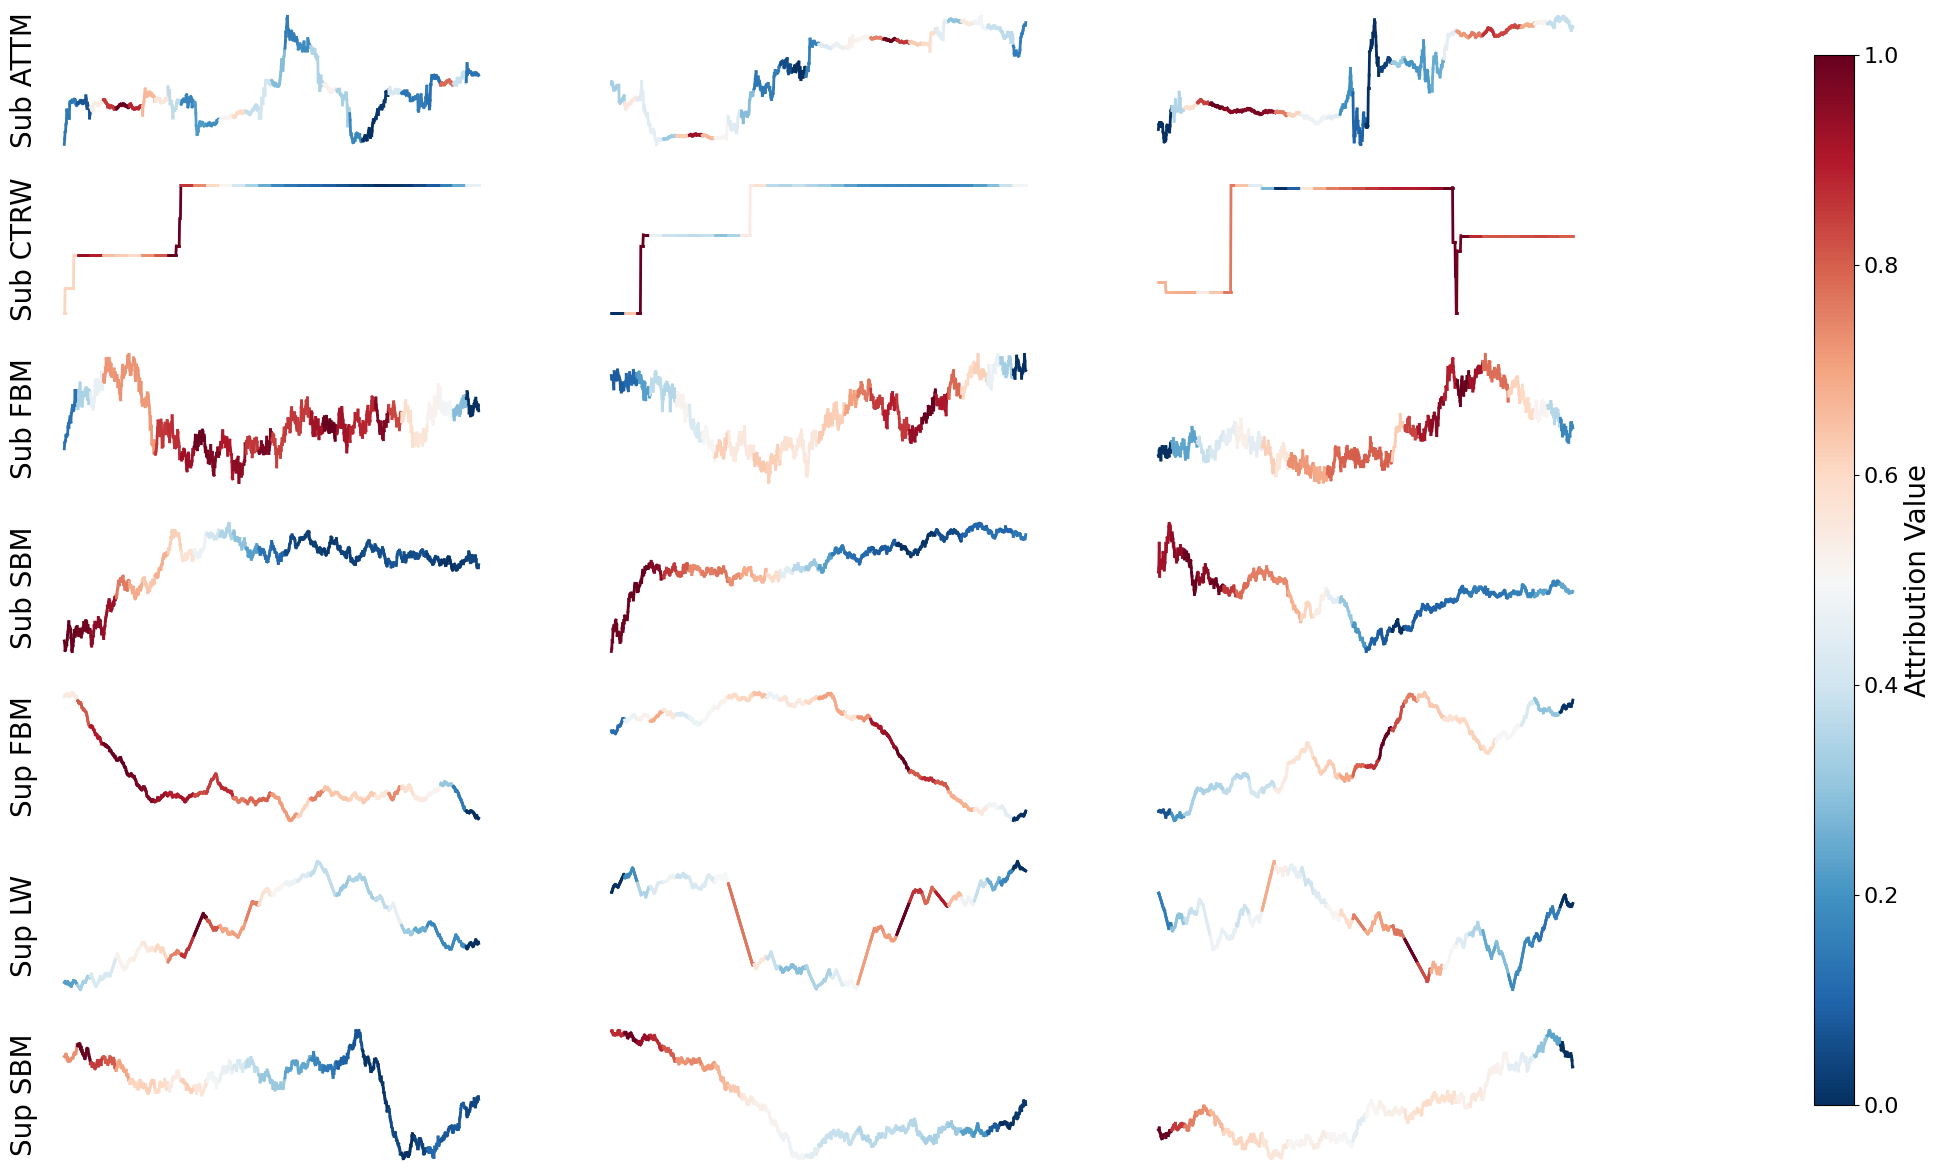

In [4]:
_draw_all_sample_traj()